# Supervised CNN baseline (log-STFT)

Минимальный **supervised baseline** для сравнения с SSL / AudioMAE: загрузка `.wav` из подвыборки → **log-STFT** → интерполяция к фиксированному размеру → **CNN** → 26 классов.

**Данные:** `cleaned_subset_200/` (~200 файлов на класс макс.), метаданные `audio_metadata_cleaned.csv` внутри этой папки.

**Чекпоинт:** `checkpoints/cnn_baseline_best.pt` (лучший по macro-F1 на валидации).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import signal
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
)
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

PROJECT_DIR = Path("/Users/katterns/ITMO/Practice")
DATA_DIR = PROJECT_DIR / "cleaned_subset_200"
METADATA_PATH = DATA_DIR / "audio_metadata_cleaned.csv"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT = CHECKPOINT_DIR / "cnn_baseline_groupnorm_best.pt"

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device:", device)
print("Data:", DATA_DIR)

Device: mps
Data: /Users/katterns/ITMO/Practice/cleaned_subset_200


In [2]:
TARGET_SR = 192_000
CLIP_SEC = 0.5  
SPEC_H, SPEC_W = 128, 256
N_FFT = 2048
HOP_LENGTH = 512
MAX_FREQ = 96_000


def resample_audio(y: np.ndarray, orig_sr: float, target_sr: float) -> np.ndarray:
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    t_old = np.linspace(0.0, len(y) / orig_sr, num=len(y), endpoint=False)
    t_new = np.linspace(0.0, len(y) / orig_sr, num=int(len(y) * target_sr / orig_sr), endpoint=False)
    return np.interp(t_new, t_old, y).astype(np.float32)


def center_crop_or_pad(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) >= target_len:
        i0 = (len(y) - target_len) // 2
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def make_log_stft(audio: np.ndarray, sr: float) -> np.ndarray:
    audio = np.asarray(audio, dtype=np.float32)
    audio = audio[np.isfinite(audio)]
    if len(audio) < 8:
        raise ValueError("Audio too short")
    nperseg = int(min(N_FFT, len(audio)))
    hop = int(min(HOP_LENGTH, max(1, nperseg // 2)))
    noverlap = max(0, nperseg - hop)
    if noverlap >= nperseg:
        noverlap = nperseg - 1
    freqs, times, zxx = signal.stft(
        audio,
        fs=sr,
        nperseg=nperseg,
        noverlap=noverlap,
        boundary="zeros",
        padded=True,
    )
    magnitude = np.abs(zxx)
    spec = np.log1p(magnitude)
    keep = freqs <= min(MAX_FREQ, sr / 2)
    return spec[keep]


def spec_to_tensor(spec: np.ndarray) -> torch.Tensor:
    x = torch.tensor(spec, dtype=torch.float32)[None, None]  # 1,1,F,T
    x = F.interpolate(x, size=(SPEC_H, SPEC_W), mode="bilinear", align_corners=False)
    x = x[0]  # 1, H, W
    x = (x - x.mean()) / (x.std().clamp_min(1e-6))
    return x

In [3]:
df = pd.read_csv(METADATA_PATH)
assert not df.empty, f"Пустой CSV: {METADATA_PATH}"

species_sorted = sorted(df["species"].unique())
label2id = {s: i for i, s in enumerate(species_sorted)}
id2label = {i: s for s, i in label2id.items()}
n_classes = len(species_sorted)

df["label"] = df["species"].map(label2id)
df["path"] = df.apply(
    lambda r: DATA_DIR / str(r["species"]) / str(r["filename"]), axis=1
)

missing = df[~df["path"].apply(lambda p: p.is_file())]
if len(missing) > 0:
    print("Нет файлов на диске:", len(missing))
    display(missing.head())
    df = df[df["path"].apply(lambda p: p.is_file())].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["label"],
)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Классов: {n_classes}")
display(train_df["species"].value_counts().head())

Train: 4348  Val: 768  Классов: 26


species
MYLU    170
EUMA    170
LACI    170
MYLE    170
EPFU    170
Name: count, dtype: int64

In [4]:
class BatWavSpectrogramDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        path = row["path"]
        y, sr = sf.read(str(path), always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=-1)
        y = resample_audio(y, float(sr), float(TARGET_SR))
        tgt = int(CLIP_SEC * TARGET_SR)
        y = center_crop_or_pad(y, tgt)
        spec = make_log_stft(y, float(TARGET_SR))
        x = spec_to_tensor(spec)
        label = int(row["label"])
        return x, label


train_ds = BatWavSpectrogramDataset(train_df)
val_ds = BatWavSpectrogramDataset(val_df)

BATCH_SIZE = 16
NUM_WORKERS = 0 

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=False,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

xb, yb = next(iter(train_loader))
print("batch x:", xb.shape, "y:", yb.shape)

batch x: torch.Size([16, 1, 128, 256]) y: torch.Size([16])


In [5]:
class BaselineCNN(nn.Module):

    def __init__(self, n_classes: int, dropout: float = 0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.GroupNorm(8, 32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)


model = BaselineCNN(n_classes=n_classes).to(device)
print(model)
with torch.no_grad():
    out = model(xb.to(device))
print("logits:", out.shape)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): GroupNorm(8, 64, eps=1e-05, affine=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): GroupNorm(8, 128, eps=1e-05, affine=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=1)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=26, bias=True)
  )
)
logits: torch.Size([16, 26])


In [6]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n = 0
    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_y = []
    all_pred = []
    total_loss = 0.0
    n = 0
    for x, y in tqdm(loader, desc="val", leave=False):
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
        pred = logits.argmax(dim=-1)
        all_y.append(y.cpu().numpy())
        all_pred.append(pred.cpu().numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return total_loss / max(n, 1), acc, bal, macro_f1, y_true, y_pred


LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 40
PATIENCE = 8

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

best_macro_f1 = -1.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}

for epoch in tqdm(range(1, MAX_EPOCHS + 1), desc="epoch"):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, acc, bal, macro_f1, y_true, y_pred = evaluate(model, val_loader)
    pred_top3 = pd.Series(y_pred).map(id2label).value_counts().head(3).to_dict()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(acc)
    history["val_macro_f1"].append(macro_f1)
    print(
        f"Epoch {epoch:02d}  train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  "
        f"acc={acc:.4f}  bal_acc={bal:.4f}  macro_f1={macro_f1:.4f}  "
        f"pred_top3={pred_top3}"
    )
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        epochs_no_improve = 0
        torch.save(
            {
                "model_state": model.state_dict(),
                "label2id": label2id,
                "id2label": id2label,
                "config": {
                    "target_sr": TARGET_SR,
                    "clip_sec": CLIP_SEC,
                    "spec_hw": (SPEC_H, SPEC_W),
                    "n_fft": N_FFT,
                    "hop_length": HOP_LENGTH,
                    "max_freq": MAX_FREQ,
                },
                "val_macro_f1": macro_f1,
                "epoch": epoch,
            },
            BEST_CKPT,
        )
        print(f"  Сохранён чекпоинт: {BEST_CKPT}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping.")
            break

print("\nЛучший macro-F1 (val):", best_macro_f1)

epoch:   0%|          | 0/40 [00:00<?, ?it/s]

train:   0%|          | 0/272 [00:00<?, ?it/s]

val:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 01  train_loss=3.2287  val_loss=3.1377  acc=0.1159  bal_acc=0.1156  macro_f1=0.0584  pred_top3={'MYGR': 195, 'LASE': 139, 'COTO': 114}
  Сохранён чекпоинт: /Users/katterns/ITMO/Practice/checkpoints/cnn_baseline_groupnorm_best.pt


train:   0%|          | 0/272 [00:00<?, ?it/s]

...

val:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 39  train_loss=1.8909  val_loss=1.8814  acc=0.4323  bal_acc=0.4311  macro_f1=0.4035  pred_top3={'MYSO': 76, 'MYSE': 74, 'MYEV': 58}


train:   0%|          | 0/272 [00:00<?, ?it/s]

val:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 40  train_loss=1.8875  val_loss=1.8821  acc=0.4362  bal_acc=0.4379  macro_f1=0.4300  pred_top3={'LABL': 83, 'MYTH': 62, 'ANPA': 56}
  Сохранён чекпоинт: /Users/katterns/ITMO/Practice/checkpoints/cnn_baseline_groupnorm_best.pt

Лучший macro-F1 (val): 0.4299841053091344


## Дообучение с меньшим LR 

In [7]:
FINETUNE_CKPT = CHECKPOINT_DIR / "cnn_baseline_groupnorm_finetune_best.pt"
PHASE1_MACRO_F1 = torch.load(BEST_CKPT, map_location=device, weights_only=False)["val_macro_f1"]

FINETUNE_MAX_EPOCHS = 10
FINETUNE_LR = LR * 0.2  
FINETUNE_PATIENCE = 8

ckpt_phase1 = torch.load(BEST_CKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt_phase1["model_state"])

optimizer_ft = torch.optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode="max", factor=0.5, patience=3, threshold=1e-4
)

best_macro_f1_ft = float(PHASE1_MACRO_F1)
epochs_no_improve_ft = 0

for epoch in tqdm(range(1, FINETUNE_MAX_EPOCHS + 1), desc="fine-tune LR"):
    tr_loss = train_one_epoch(model, train_loader, optimizer_ft, criterion)
    val_loss, acc, bal, macro_f1, y_true, y_pred = evaluate(model, val_loader)
    scheduler.step(macro_f1)

    pred_top3 = pd.Series(y_pred).map(id2label).value_counts().head(3).to_dict()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(acc)
    history["val_macro_f1"].append(macro_f1)

    lr_now = optimizer_ft.param_groups[0]["lr"]
    print(
        f"FT {epoch:02d}/{FINETUNE_MAX_EPOCHS}  lr={lr_now:.2e}  "
        f"train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  "
        f"acc={acc:.4f}  bal_acc={bal:.4f}  macro_f1={macro_f1:.4f}  pred_top3={pred_top3}"
    )

    if macro_f1 > best_macro_f1_ft:
        best_macro_f1_ft = macro_f1
        epochs_no_improve_ft = 0
        torch.save(
            {
                "model_state": model.state_dict(),
                "label2id": label2id,
                "id2label": id2label,
                "config": ckpt_phase1["config"],
                "val_macro_f1": macro_f1,
                "phase": "finetune_lr",
                "epoch_ft": epoch,
                "lr_final": lr_now,
            },
            FINETUNE_CKPT,
        )
        print(f"  Сохранён finetune чекпоинт: {FINETUNE_CKPT}")
    else:
        epochs_no_improve_ft += 1
        if epochs_no_improve_ft >= FINETUNE_PATIENCE:
            print("Early stopping (fine-tune).")
            break

if best_macro_f1_ft > PHASE1_MACRO_F1:
    BEST_CKPT = FINETUNE_CKPT
    print(f"\nЛучшие веса после fine-tune (macro_f1={best_macro_f1_ft:.4f}). ACTIVE: {BEST_CKPT}")
else:
    print(f"\nFine-tune не превзошёл phase1 ({PHASE1_MACRO_F1:.4f} vs {best_macro_f1_ft:.4f}). Оставляем BEST_CKPT={BEST_CKPT}")


fine-tune LR:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/272 [00:00<?, ?it/s]

val:   0%|          | 0/48 [00:00<?, ?it/s]

FT 01/10  lr=2.00e-04  train_loss=1.7840  val_loss=1.7543  acc=0.4648  bal_acc=0.4646  macro_f1=0.4423  pred_top3={'LABL': 49, 'MYLE': 46, 'MYSO': 44}
  Сохранён finetune чекпоинт: /Users/katterns/ITMO/Practice/checkpoints/cnn_baseline_groupnorm_finetune_best.pt


train:   0%|          | 0/272 [00:00<?, ?it/s]

...

val:   0%|          | 0/48 [00:00<?, ?it/s]

FT 09/10  lr=2.00e-04  train_loss=1.7348  val_loss=1.7324  acc=0.4688  bal_acc=0.4684  macro_f1=0.4489  pred_top3={'LABL': 54, 'MYLE': 47, 'MYTH': 43}


train:   0%|          | 0/272 [00:00<?, ?it/s]

val:   0%|          | 0/48 [00:00<?, ?it/s]

FT 10/10  lr=2.00e-04  train_loss=1.7309  val_loss=1.7333  acc=0.4674  bal_acc=0.4670  macro_f1=0.4438  pred_top3={'MYLE': 53, 'LAIN': 48, 'TABR': 46}

Лучшие веса после fine-tune (macro_f1=0.4534). ACTIVE: /Users/katterns/ITMO/Practice/checkpoints/cnn_baseline_groupnorm_finetune_best.pt


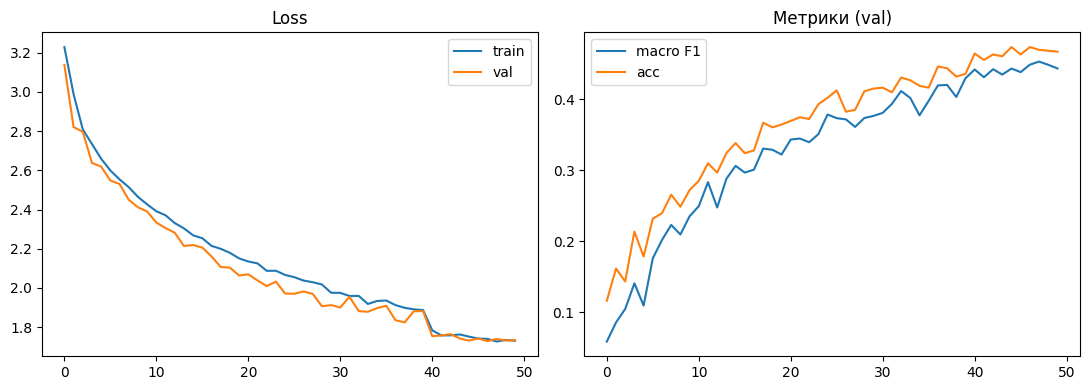

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].legend()
ax[1].plot(history["val_macro_f1"], label="macro F1")
ax[1].plot(history["val_acc"], label="acc")
ax[1].set_title("Метрики (val)")
ax[1].legend()
plt.tight_layout()
plt.show()

val:   0%|          | 0/48 [00:00<?, ?it/s]

Validation — accuracy: 0.4700520833333333
Validation — balanced accuracy: 0.47082449160035367
Validation — macro F1: 0.45343314999339257

              precision    recall  f1-score   support

        ANPA       0.32      0.23      0.27        30
        COTO       0.58      0.44      0.50        25
        EPFU       0.27      0.27      0.27        30
        EUMA       0.76      0.83      0.79        30
        LABL       0.25      0.54      0.35        24
        LABO       0.14      0.13      0.14        30
        LACI       0.08      0.03      0.05        30
        LAIN       0.56      0.77      0.65        30
        LANO       0.68      0.43      0.53        30
        LASE       0.82      0.60      0.69        30
        MYCA       0.29      0.23      0.26        30
        MYCI       0.44      0.37      0.40        30
        MYEV       0.30      0.20      0.24        30
        MYGR       0.85      0.77      0.81        30
        MYLE       0.61      0.63      0.62        

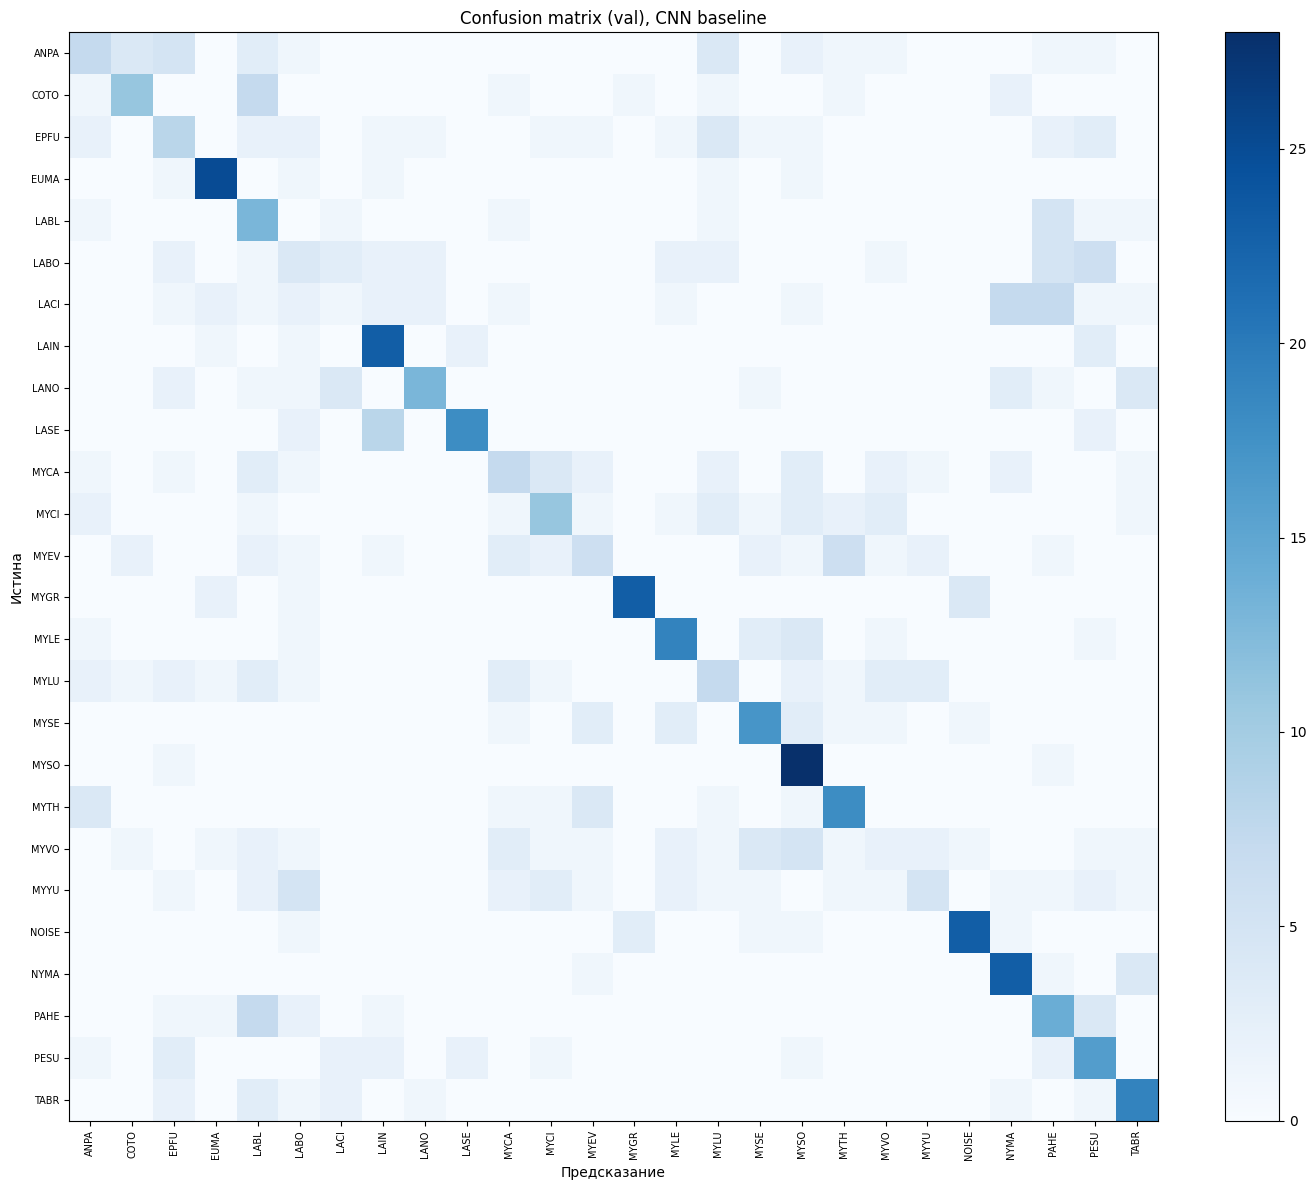

In [9]:
ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])

_, acc, bal, macro_f1, y_true, y_pred = evaluate(model, val_loader)
print("Validation — accuracy:", acc)
print("Validation — balanced accuracy:", bal)
print("Validation — macro F1:", macro_f1)
print()
print(classification_report(y_true, y_pred, target_names=species_sorted, zero_division=0))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(species_sorted, rotation=90, fontsize=7)
ax.set_yticklabels(species_sorted, fontsize=7)
ax.set_ylabel("Истина")
ax.set_xlabel("Предсказание")
ax.set_title("Confusion matrix (val), CNN baseline")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()